# TP1 — Aprendizaje Profundo: MLP vs CNNs en un Escenario Realista

## Overfitting, sesgo inductivo, regularización y desbalance de clases

Este trabajo práctico toma como punto de partida el experimento clásico **MLP vs CNN sobre MNIST**, pero lo traslada a un escenario mucho más cercano a los problemas reales de aprendizaje automático: **pocos datos, desbalance de clases y necesidad de regularización**.

En el MNIST original, con 60.000 imágenes de entrenamiento bien balanceadas, el problema es tan sencillo que muchas diferencias importantes entre modelos quedan ocultas. En cambio, si reducimos drásticamente el conjunto de entrenamiento y además introducimos un desbalance severo, aparecen fenómenos que sí son fundamentales en Deep Learning:

- overfitting;
- diferencias reales entre una arquitectura densa y una convolucional;
- necesidad de usar regularización explícita e implícita;
- importancia de usar métricas más ricas que la accuracy.

### Idea clave
Este notebook no busca “ganarle a MNIST”, sino usar un problema controlado para estudiar **cómo piensan y cómo fallan los modelos**.

### Objetivos pedagógicos
Al finalizar este trabajo práctico deberías poder:

- distinguir memorizar de generalizar;
- explicar por qué una CNN suele generalizar mejor que una MLP en imágenes;
- entender el rol de dropout, weight decay, data augmentation y class-weighted loss;
- interpretar correctamente accuracy, balanced accuracy y macro-F1;
- analizar curvas de entrenamiento, matrices de confusión y errores por clase.

### Hoja de ruta
1. Construimos un MNIST reducido y desbalanceado.
2. Visualizamos el problema y cuantificamos el desbalance.
3. Definimos una MLP y una CNN.
4. Implementamos el loop de entrenamiento.
5. Entrenamos variantes baseline y regularizadas.
6. Analizamos resultados con métricas globales y por clase.
7. Discutimos qué nos enseñan los resultados sobre Deep Learning.


## 0. Nota para Google Colab

Este notebook está pensado para correr en **Google Colab**. Se recomienda activar GPU desde:

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**

Aun así, el diseño del dataset hace que también sea razonablemente ejecutable en CPU.

### Importante
En esta versión del TP **no está todo resuelto**. Hay secciones `TODO` que debés completar vos:

- definición de la **MLP**;
- definición de la **CNN**;
- implementación de la **función de pérdida**;
- implementación del **loop de entrenamiento y validación**.

La idea es que el notebook te guíe, pero que la parte central del experimento la construyas vos.


In [1]:
# Si trabajás en un entorno limpio, descomentá esta línea:
!pip -q install torch torchvision numpy pandas matplotlib scikit-learn

import os
import time
import random
import warnings
import copy
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "figure.facecolor": "white",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
})

warnings.filterwarnings("ignore", category=UserWarning)

print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso: {device.type.upper()}")


PyTorch version: 2.9.0+cu126
Dispositivo en uso: CUDA


## 1. Reproducibilidad científica

En aprendizaje profundo, dos corridas aparentemente idénticas pueden producir resultados distintos por varios motivos:

- inicialización aleatoria de los pesos,
- orden aleatorio de los minibatches,
- operaciones no determinísticas en GPU.

Fijar semillas no garantiza identidad absoluta en todos los entornos, pero sí reduce muchísimo la variabilidad y vuelve las comparaciones más justas.

### Mensaje para llevarse
Si querés comparar modelos, primero necesitás **controlar el experimento**.


In [2]:
def seed_everything(seed: int = 42) -> None:
    """Fija semillas de Python, NumPy y PyTorch."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Semillas fijadas correctamente.")


Semillas fijadas correctamente.


## 2. Configuración global del experimento

Vamos a construir un subset muy pequeño y desbalanceado del conjunto de entrenamiento original.

### Idea clave
No estamos cambiando el dominio del problema. Seguimos trabajando con **MNIST**. Lo que cambia es el régimen estadístico:

- menos datos;
- clases frecuentes y clases raras;
- mayor posibilidad de sobreajuste;
- mayor necesidad de métricas robustas.

### Qué deberías observar
Las clases **0 y 1** tendrán muchísimos más ejemplos que **8 y 9**. Eso vuelve al entrenamiento mucho más interesante que el MNIST estándar.


In [3]:
CONFIG = {
    "seed": 42,
    "data_dir": "./data",
    "batch_size": 128,
    "num_workers": 2,
    "epochs": 15,
    "learning_rate": 1e-3,
    "val_fraction": 0.20,
    "early_stopping_patience": None,  # por ejemplo: 5
    "subset_counts": {
        0: 800,
        1: 800,
        2: 400,
        3: 400,
        4: 100,
        5: 100,
        6: 100,
        7: 100,
        8: 50,
        9: 50,
    },
}

total_subset = sum(CONFIG["subset_counts"].values())
print(f"Tamaño total del dataset reducido (train + val): {total_subset}")
pd.Series(CONFIG["subset_counts"]).rename("cantidad")


Tamaño total del dataset reducido (train + val): 2900


,cantidad
0,800
1,800
2,400
3,400
4,100
5,100
6,100
7,100
8,50
9,50


## 3. Un repaso conceptual antes del código

### 3.1 Capacidad del modelo y overfitting
Una red con alta capacidad puede representar funciones muy complejas. Si el conjunto de entrenamiento es pequeño, esa capacidad puede usarse para memorizar ejemplos particulares en lugar de extraer regularidades que generalicen.

- **Train loss muy baja** no implica buen modelo.
- El indicador importante es el comportamiento sobre **validación** y **test**.

### 3.2 Sesgo inductivo
El sesgo inductivo es el conjunto de suposiciones que hace el modelo para extrapolar a ejemplos no vistos.

- Una **MLP** toma la imagen y la aplana en un vector. Trata a cada píxel como una entrada genérica, sin privilegiar la estructura 2D.
- Una **CNN** usa filtros locales y comparte pesos. Asume que la estructura local importa y que ciertos patrones pueden reaparecer en distintas posiciones.

### 3.3 Regularización
Vamos a usar dos tipos de regularización:

- **Explícita**: dropout, weight decay, class-weighted loss.
- **Implícita / por datos**: data augmentation.

### 3.4 Métricas y desbalance
En datasets desbalanceados la accuracy puede ser engañosa. Por eso usamos además:

- **Balanced Accuracy**: promedio del recall por clase.
- **Macro-F1**: promedio no ponderado del F1 de cada clase.

### Error conceptual frecuente
Pensar que “si la accuracy es alta, el modelo está bien”. En problemas desbalanceados eso puede ser completamente falso.


## 4. Construcción del dataset reducido y desbalanceado

Vamos a:

- descargar MNIST original,
- seleccionar una cantidad fija por clase,
- partir ese subset en entrenamiento y validación de forma estratificada,
- dejar el conjunto de test intacto.


In [4]:
# Transformaciones base
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Data augmentation suave para entrenamiento
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=15, translate=(0.08, 0.08), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train_raw = datasets.MNIST(root=CONFIG["data_dir"], train=True, download=True)
mnist_test = datasets.MNIST(root=CONFIG["data_dir"], train=False, download=True, transform=eval_transform)

print(f"MNIST original - Train: {len(mnist_train_raw)} | Test: {len(mnist_test)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 357kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.2MB/s]

MNIST original - Train: 60000 | Test: 10000


In [5]:
def build_reduced_indices(targets: np.ndarray, subset_counts: Dict[int, int], seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    final_indices = []

    for cls, count in subset_counts.items():
        cls_indices = np.where(targets == cls)[0]
        rng.shuffle(cls_indices)

        if count > len(cls_indices):
            raise ValueError(f"La clase {cls} pidió {count} ejemplos, pero sólo hay {len(cls_indices)}.")
        final_indices.extend(cls_indices[:count].tolist())

    final_indices = np.array(final_indices)
    rng.shuffle(final_indices)
    return final_indices


def stratified_train_val_split(
    indices: np.ndarray,
    targets: np.ndarray,
    val_fraction: float = 0.20,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    train_idx, val_idx = [], []

    for cls in sorted(np.unique(targets[indices])):
        cls_indices = indices[targets[indices] == cls].copy()
        rng.shuffle(cls_indices)

        n_val = max(1, int(round(len(cls_indices) * val_fraction)))
        val_idx.extend(cls_indices[:n_val].tolist())
        train_idx.extend(cls_indices[n_val:].tolist())

    train_idx = np.array(train_idx)
    val_idx = np.array(val_idx)
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx


targets_np = mnist_train_raw.targets.cpu().numpy()
reduced_indices = build_reduced_indices(targets_np, CONFIG["subset_counts"], CONFIG["seed"])
train_indices, val_indices = stratified_train_val_split(
    reduced_indices,
    targets_np,
    val_fraction=CONFIG["val_fraction"],
    seed=CONFIG["seed"],
)

print(f"Nuestro setup - Train: {len(train_indices)} | Val: {len(val_indices)} | Test: {len(mnist_test)}")


Nuestro setup - Train: 2320 | Val: 580 | Test: 10000


In [6]:
class TensorMNISTDataset(Dataset):
    """Dataset auxiliar para aplicar transforms a subconjuntos indexados de MNIST."""
    def __init__(self, images: torch.Tensor, labels: torch.Tensor, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])
        pil_img = TF.to_pil_image(image)

        if self.transform is not None:
            x = self.transform(pil_img)
        else:
            x = TF.to_tensor(pil_img)
        return x, label


all_images = mnist_train_raw.data
all_labels = mnist_train_raw.targets

train_images = all_images[train_indices]
train_labels = all_labels[train_indices]
val_images = all_images[val_indices]
val_labels = all_labels[val_indices]

train_dataset_plain = TensorMNISTDataset(train_images, train_labels, transform=eval_transform)
train_dataset_aug = TensorMNISTDataset(train_images, train_labels, transform=train_transform_aug)
val_dataset = TensorMNISTDataset(val_images, val_labels, transform=eval_transform)

print("Datasets preparados.")


Datasets preparados.


## 5. Análisis exploratorio visual

Antes de entrenar una red, conviene entender bien qué distribución de datos verá el modelo.

### Qué mirar
- la severidad del desbalance;
- cuántos ejemplos realmente quedan por clase;
- cómo lucen las imágenes de cada clase;
- qué tan fuerte es el augmentation aplicado.


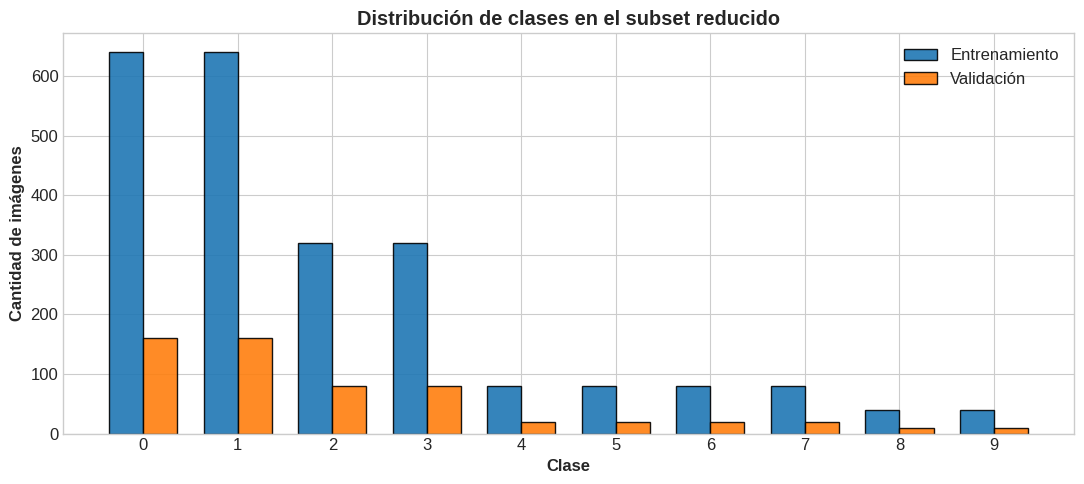

Razón entre la clase mayoritaria 0 y la minoritaria 9 en train: 16.0 a 1


In [7]:
def count_labels(labels: torch.Tensor) -> Dict[int, int]:
    unique, counts = torch.unique(labels, return_counts=True)
    return {int(k): int(v) for k, v in zip(unique, counts)}

train_counts = count_labels(train_labels)
val_counts = count_labels(val_labels)

classes = list(range(10))
train_hist = [train_counts.get(c, 0) for c in classes]
val_hist = [val_counts.get(c, 0) for c in classes]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(classes))
width = 0.36

ax.bar(x - width/2, train_hist, width=width, label="Entrenamiento", edgecolor="black", alpha=0.9)
ax.bar(x + width/2, val_hist, width=width, label="Validación", edgecolor="black", alpha=0.9)

ax.set_xticks(classes)
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución de clases en el subset reducido")
ax.legend()
plt.tight_layout()
plt.show()

ratio_major_minor = train_counts[0] / train_counts[9]
print(f"Razón entre la clase mayoritaria 0 y la minoritaria 9 en train: {ratio_major_minor:.1f} a 1")


### Interpretación
La red verá muchas más imágenes de algunas clases que de otras. Eso crea un incentivo estadístico a favorecer a las clases frecuentes.

### Mensaje para llevarse
Si no hacemos nada, el modelo puede volverse “perezoso”: aprende muy bien las clases comunes y rinde mal en las raras.


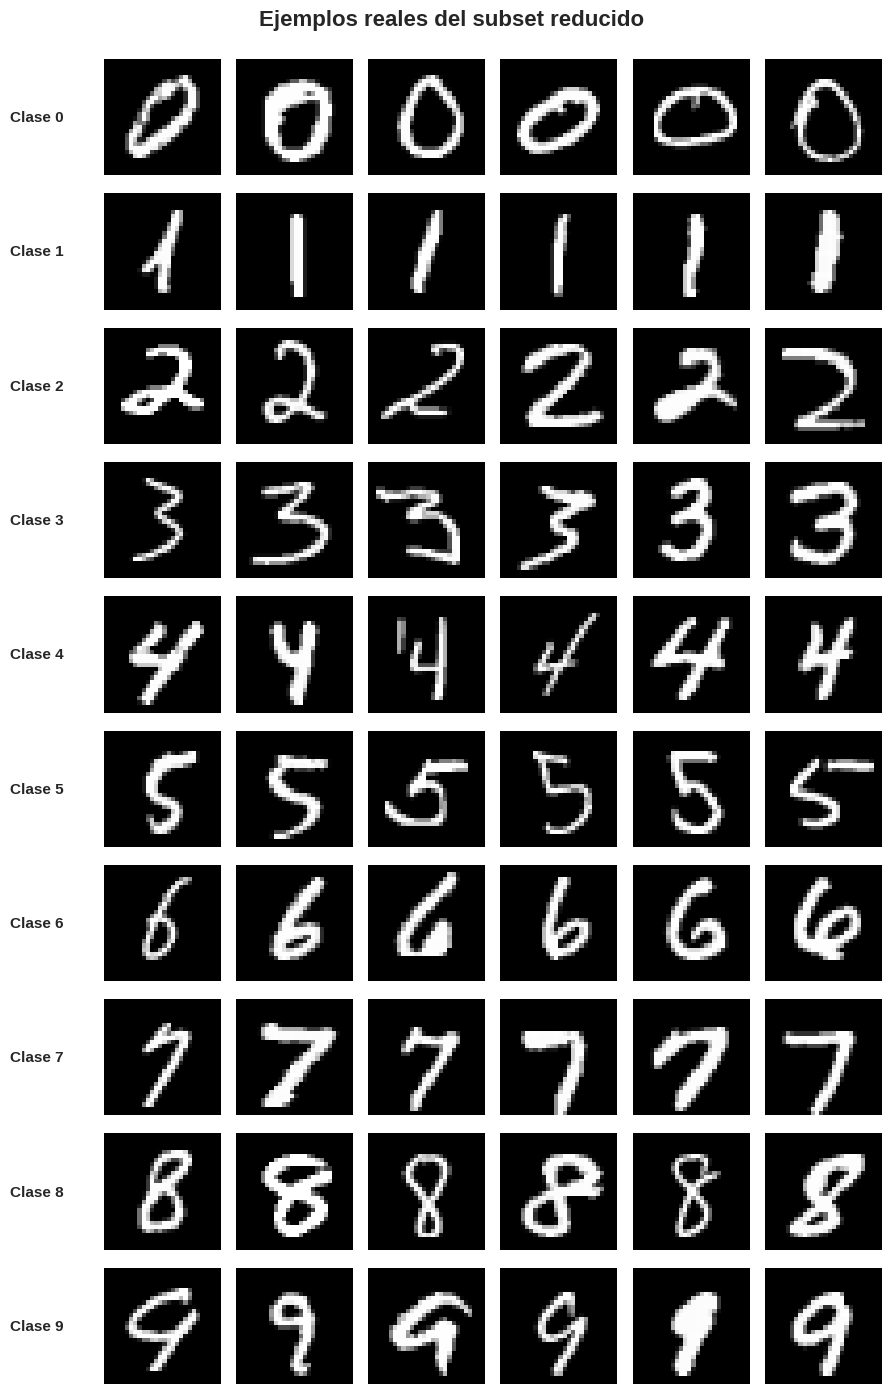

In [8]:
def show_examples_per_class(images: torch.Tensor, labels: torch.Tensor, n: int = 6):
    fig, axes = plt.subplots(10, n, figsize=(1.5 * n, 14))
    fig.suptitle("Ejemplos reales del subset reducido", fontsize=16, fontweight="bold", y=0.995)

    for cls in range(10):
        cls_indices = torch.where(labels == cls)[0][:n]
        for j in range(n):
            ax = axes[cls, j]
            if j < len(cls_indices):
                idx = cls_indices[j]
                ax.imshow(images[idx], cmap="gray")
            ax.axis("off")
            if j == 0:
                ax.text(-0.35, 0.5, f"Clase {cls}", va="center", ha="right",
                        transform=ax.transAxes, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_examples_per_class(train_images, train_labels, n=6)


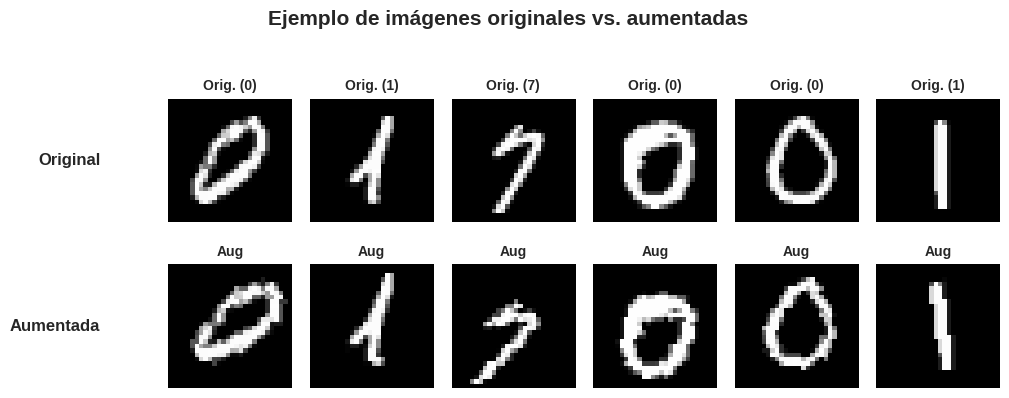

In [9]:
def show_augmentation_examples(dataset_plain: Dataset, dataset_aug: Dataset, n: int = 6):
    fig, axes = plt.subplots(2, n, figsize=(1.7 * n, 4))
    fig.suptitle("Ejemplo de imágenes originales vs. aumentadas", fontsize=15, fontweight="bold", y=1.03)

    for j in range(n):
        x_plain, y = dataset_plain[j]
        x_aug, _ = dataset_aug[j]

        axes[0, j].imshow(x_plain.squeeze().numpy(), cmap="gray")
        axes[0, j].set_title(f"Orig. ({y})", fontsize=10)
        axes[0, j].axis("off")

        axes[1, j].imshow(x_aug.squeeze().numpy(), cmap="gray")
        axes[1, j].set_title("Aug", fontsize=10)
        axes[1, j].axis("off")

    axes[0, 0].text(-0.55, 0.5, "Original", va="center", ha="right",
                    transform=axes[0, 0].transAxes, fontweight="bold")
    axes[1, 0].text(-0.55, 0.5, "Aumentada", va="center", ha="right",
                    transform=axes[1, 0].transAxes, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_augmentation_examples(train_dataset_plain, train_dataset_aug, n=6)


### Idea clave
El augmentation no inventa clases nuevas, pero sí vuelve el entrenamiento más exigente. Obliga a la red a aprender representaciones más estables ante pequeñas transformaciones.

### Error conceptual frecuente
Pensar que augmentation “mejora” la validación porque sí. En realidad, mejora la generalización porque hace más difícil el entrenamiento y desalienta la memorización exacta.


## 6. Cómo vamos a tratar el desbalance

En este notebook usaremos principalmente **class-weighted loss**, es decir, una función de pérdida que penaliza más los errores sobre clases minoritarias.

También dejamos implementado un `WeightedRandomSampler` como extensión opcional.

Si \(n_c\) es la cantidad de ejemplos de la clase \(c\), definimos un peso inversamente proporcional a su frecuencia:

\[
w_c = \frac{N}{K\, n_c}
\]

donde:

- \(N\) es el total de ejemplos,
- \(K\) es el número de clases.

Así, las clases poco frecuentes reciben mayor peso.


In [10]:
def compute_class_weights(labels: torch.Tensor, num_classes: int = 10) -> torch.Tensor:
    counts = torch.bincount(labels, minlength=num_classes).float()
    weights = counts.sum() / (num_classes * counts)
    return weights

class_weights = compute_class_weights(train_labels)

weights_df = pd.DataFrame({
    "clase": list(range(10)),
    "cantidad_train": [train_counts[c] for c in range(10)],
    "peso_loss": class_weights.numpy(),
})
weights_df


,clase,cantidad_train,peso_loss
0,0,640,0.3625
1,1,640,0.3625
2,2,320,0.7250
3,3,320,0.7250
4,4,80,2.9000
5,5,80,2.9000
6,6,80,2.9000
7,7,80,2.9000
8,8,40,5.8000
9,9,40,5.8000


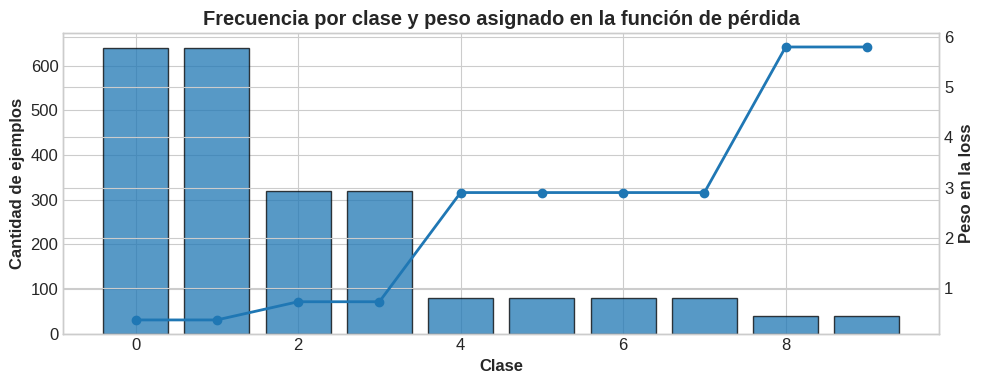

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(weights_df["clase"], weights_df["cantidad_train"], alpha=0.75, edgecolor="black", label="Cantidad train")
ax2.plot(weights_df["clase"], weights_df["peso_loss"], marker="o", linewidth=2, label="Peso en la loss")

ax1.set_xlabel("Clase")
ax1.set_ylabel("Cantidad de ejemplos")
ax2.set_ylabel("Peso en la loss")
ax1.set_title("Frecuencia por clase y peso asignado en la función de pérdida")
plt.tight_layout()
plt.show()


In [12]:
def make_weighted_sampler(labels: torch.Tensor) -> WeightedRandomSampler:
    class_counts = torch.bincount(labels)
    inv_freq = 1.0 / class_counts.float()
    sample_weights = inv_freq[labels]
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(labels), replacement=True)

weighted_sampler = make_weighted_sampler(train_labels)
print("WeightedRandomSampler preparado (extensión opcional).")


WeightedRandomSampler preparado (extensión opcional).


## 7. DataLoaders

Creamos una función flexible para construir `DataLoaders` según cada experimento.

### Decisión metodológica
En los experimentos principales:

- usaremos augmentation sólo cuando corresponda;
- no usaremos `weighted_sampling` en simultáneo con `class-weighted loss` para no mezclar demasiados efectos a la vez.

Eso permite que el análisis sea más limpio.


In [ ]:
def make_loaders(
    batch_size: int = 128,
    augmentation: bool = False,
    weighted_sampling: bool = False,
    num_workers: int = 2,
):
    train_ds = train_dataset_aug if augmentation else train_dataset_plain

    if weighted_sampling:
        sampler = make_weighted_sampler(train_labels)
        train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            sampler=sampler,
            num_workers=num_workers,
            pin_memory=torch.cuda.is_available(),
        )
    else:
        train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=torch.cuda.is_available(),
        )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = DataLoader(
        mnist_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader, test_loader


## 8. Modelos: una MLP y una CNN

Vamos a comparar dos familias de modelos:

- **MLP**: aplana la imagen y trabaja sobre un vector de 784 entradas.
- **CNN**: usa convoluciones y pooling para explotar la estructura espacial.

### Idea clave
La pregunta no es sólo cuál rinde mejor, sino **por qué**.

## TODO 1 — Implementar las arquitecturas
Completá las clases `MLPClassifier` y `SimpleCNN`.

### Sugerencias mínimas
- **MLP**: dos capas ocultas, activación `ReLU`, dropout opcional.
- **CNN**: al menos dos bloques convolucionales con `Conv2d + ReLU + MaxPool2d`, seguidos por un clasificador final.
- Ambas deben devolver **logits** de tamaño `(batch_size, 10)`.

### Pista
No apliques `softmax` dentro de `forward` si vas a usar `CrossEntropyLoss`.


In [ ]:
class MLPClassifier(nn.Module):
    """Perceptrón multicapa para imágenes 28x28."""
    def __init__(self, hidden_dims=(256, 128), dropout=0.0, num_classes=10):
        super().__init__()

        self.flatten = nn.Flatten()

        self.layers = nn.Sequential(
            nn.Linear(28 * 28, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),# Válido, pytorch lo toma como identidad con dropout=0.0
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x


In [ ]:
class SimpleCNN(nn.Module):
    """CNN pequeña para estudiar sesgo inductivo en MNIST."""
    def __init__(self, base_channels=32, dropout=0.0, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear((base_channels * 2) * 7 * 7, (base_channels * 4)),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear((base_channels * 4), num_classes)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [16]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


,modelo,parámetros
0,MLP,235146
1,CNN,421642


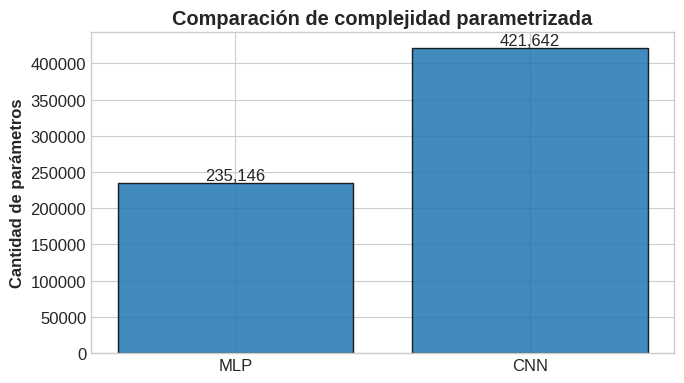

In [17]:
# Ejecutá esta celda recién después de completar las arquitecturas.
try:
    param_df = pd.DataFrame({
        "modelo": ["MLP", "CNN"],
        "parámetros": [count_parameters(MLPClassifier()), count_parameters(SimpleCNN())],
    })
    display(param_df)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(param_df["modelo"], param_df["parámetros"], edgecolor="black", alpha=0.85)
    ax.set_ylabel("Cantidad de parámetros")
    ax.set_title("Comparación de complejidad parametrizada")
    for bar, value in zip(bars, param_df["parámetros"]):
        ax.text(bar.get_x() + bar.get_width()/2, value, f"{value:,}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()
except NotImplementedError:
    print("Completá primero las arquitecturas para comparar parámetros.")


Así como se definió en la consigna, el MLP tiene 235146 parametros, mientras que la CNN, con 32 canales base se me iba a los 421642, haciendo que la comparación sea injusta (crying baby vs hydrogen bomb). Así que cambié el base_chanels defaul a 16, llegando a 105866. De momento voy a ir con este valor, ya que como vimos en la clase, las CNN son más optimas al aprovechar la correlación espacial de las imagenes, por lo que con menos parametros pueden hacer lo mismo e incluso más que los MLP. A posteriori podría probar con 24 (parametros 237514)

NOTA: eliminar

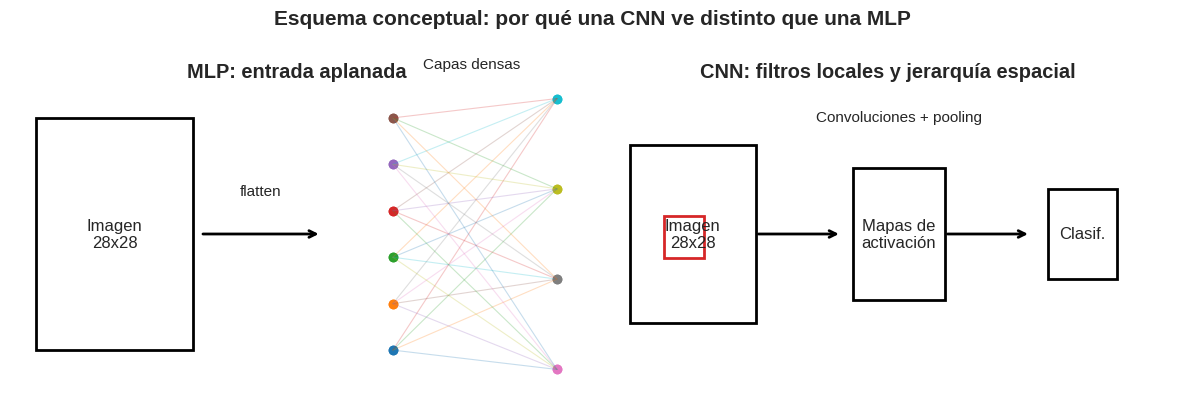

In [18]:
def plot_mlp_vs_cnn_schema():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Esquema MLP
    ax = axes[0]
    ax.set_title("MLP: entrada aplanada")
    ax.add_patch(Rectangle((0.05, 0.20), 0.22, 0.60, fill=False, linewidth=2))
    ax.text(0.16, 0.50, "Imagen\n28x28", ha="center", va="center", fontsize=12)
    ax.annotate("", xy=(0.45, 0.50), xytext=(0.28, 0.50), arrowprops=dict(arrowstyle="->", lw=2))
    ax.text(0.365, 0.60, "flatten", ha="center", fontsize=11)
    for y in np.linspace(0.20, 0.80, 6):
        ax.plot([0.55, 0.55], [y, y], marker="o")
    for y in np.linspace(0.15, 0.85, 4):
        ax.plot([0.78, 0.78], [y, y], marker="o")
    for y1 in np.linspace(0.20, 0.80, 6):
        for y2 in np.linspace(0.15, 0.85, 4):
            ax.plot([0.55, 0.78], [y1, y2], alpha=0.25, linewidth=0.8)
    ax.text(0.66, 0.93, "Capas densas", ha="center", fontsize=11)
    ax.axis("off")

    # Esquema CNN
    ax = axes[1]
    ax.set_title("CNN: filtros locales y jerarquía espacial")
    ax.add_patch(Rectangle((0.05, 0.20), 0.22, 0.60, fill=False, linewidth=2))
    ax.text(0.16, 0.50, "Imagen\n28x28", ha="center", va="center", fontsize=12)
    ax.add_patch(Rectangle((0.11, 0.42), 0.07, 0.14, fill=False, linewidth=2, edgecolor="tab:red"))
    ax.annotate("", xy=(0.42, 0.50), xytext=(0.27, 0.50), arrowprops=dict(arrowstyle="->", lw=2))
    ax.add_patch(Rectangle((0.44, 0.28), 0.16, 0.44, fill=False, linewidth=2))
    ax.text(0.52, 0.50, "Mapas de\nactivación", ha="center", va="center")
    ax.annotate("", xy=(0.75, 0.50), xytext=(0.60, 0.50), arrowprops=dict(arrowstyle="->", lw=2))
    ax.add_patch(Rectangle((0.78, 0.35), 0.12, 0.30, fill=False, linewidth=2))
    ax.text(0.84, 0.50, "Clasif.", ha="center", va="center")
    ax.text(0.52, 0.88, "Convoluciones + pooling", ha="center", fontsize=11)
    ax.axis("off")

    fig.suptitle("Esquema conceptual: por qué una CNN ve distinto que una MLP", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_mlp_vs_cnn_schema()


### Interpretación
Aunque una CNN pueda tener más parámetros, su estructura está mucho mejor alineada con la geometría del problema.

### Error conceptual frecuente
Pensar que “más parámetros = necesariamente más overfitting”. La arquitectura importa. El sesgo inductivo también controla cómo se usa esa capacidad.


## 9. Funciones de evaluación

Estas funciones sí las dejamos implementadas porque no forman parte del núcleo del ejercicio. Nos servirán para analizar los modelos una vez entrenados.

Vamos a registrar:

- loss de entrenamiento y validación,
- accuracy,
- balanced accuracy,
- macro-F1.

Además, vamos a guardar el mejor modelo según la **macro-F1 de validación**, porque en presencia de desbalance esa métrica resume mejor el rendimiento por clase.


In [ ]:
@torch.no_grad()
def collect_predictions(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    all_logits, all_targets = [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_targets.append(y.cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    preds = all_logits.argmax(dim=1)
    return preds.numpy(), all_targets.numpy()


def compute_metrics(y_true, y_pred) -> Dict[str, float]:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


## 10. TODO 2 — Implementar el loop de entrenamiento

Ahora toca completar la parte más importante del TP.

Debés implementar:

1. `run_epoch`: una época de entrenamiento o validación.
2. `train_model`: el entrenamiento completo a lo largo de varias épocas.

### Qué debería hacer `run_epoch`
- cambiar entre modo `train()` y `eval()`;
- recorrer el `loader`;
- mover tensores a `device`;
- hacer forward;
- calcular la loss;
- si hay optimizador, hacer:
  - `optimizer.zero_grad()`
  - `loss.backward()`
  - `optimizer.step()`
- acumular la pérdida promedio.

### Qué debería hacer `train_model`
- construir la `criterion`;
- construir el optimizador (`AdamW`);
- llamar a `run_epoch` en train y val;
- calcular métricas;
- guardar el mejor estado según `val_macro_f1`;
- devolver:
  - modelo,
  - historial,
  - tiempo de ejecución.

### Pistas
- Si querés usar pérdida ponderada por clase, usá `nn.CrossEntropyLoss(weight=weights)`.
- Si no querés ponderar clases, usá simplemente `nn.CrossEntropyLoss()`.
- `CrossEntropyLoss` espera **logits**, no probabilidades.


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, device=device):
    """Ejecuta una época completa de train o val y devuelve la loss promedio."""

    total_loss = 0.0
    correct = 0
    total = 0
    predictions = []
    true_labels = []

    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    grad_context = torch.enable_grad() if is_train else torch.no_grad()

    with grad_context:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            if is_train:
                optimizer.zero_grad()
            model_out = model(images)
            loss = criterion(model_out, labels)

            if is_train:
                loss.backward()
                optimizer.step()
            
            total_loss += loss.item() * images.size(0)

            _, predicted = model_out.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            predictions.append(predicted.cpu())
            true_labels.append(labels.cpu())
        predictions = torch.cat(predictions, dim=0)
        true_labels = torch.cat(true_labels, dim=0)
    
    return total_loss / total, 100.0 * correct / total, predictions, true_labels


devuelvo loss, acc, predicciones y etiquetas. Si no lo hiciese, debería usar collect predictions, pasando los datos por validación dos veces (poco eficiente). Así solo pasan una vez

In [21]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    weight_decay: float = 0.0,
    class_weighted_loss: bool = False,
    early_stopping_patience: Optional[int] = None,
    device: torch.device = device,
):
    """Entrena un modelo, guarda el mejor estado y devuelve history."""

    model = model.to(device)

    if class_weighted_loss:
        train_labels = train_loader.dataset.labels
        class_counts = torch.bincount(train_labels)
        weights = 1.0 / class_counts.float()
        weights = weights.to(device)
        criterion = nn.CrossEntropyLoss(weight=weights)
    else:
        criterion = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'train_bal_acc': [], 'val_loss': [], 'val_bal_acc': [], 'train_macro_f1': [], 'val_macro_f1': [], "train_accuracy": [], 'val_accuracy': []}
    best_model ={'acc':0, 'bacc':0, 'macro_f1':0, 'state':None}

    epochs_no_improve = 0

    start_time = time.time()

    for i in range(epochs):
        
        print(f"Época {i+1}/{epochs}")
        if early_stopping_patience is not None and epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping en época {i+1} tras {epochs_no_improve} sin mejora.")
            break

        train_loss, train_acc, y_pred_train, y_true_train = run_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, y_pred_val, y_true_val = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

        metrics_train = compute_metrics(y_true_train, y_pred_train)
        metrics_val = compute_metrics(y_true_val, y_pred_val)

        history['train_loss'].append(train_loss)
        history['train_bal_acc'].append(metrics_train['balanced_accuracy'])
        history['train_macro_f1'].append(metrics_train['macro_f1'])
        history['train_accuracy'].append(metrics_train['accuracy'])

        history['val_loss'].append(val_loss)
        history['val_bal_acc'].append(metrics_val['balanced_accuracy'])
        history['val_macro_f1'].append(metrics_val['macro_f1'])
        history['val_accuracy'].append(metrics_val['accuracy'])

        if metrics_val['macro_f1'] > best_model['macro_f1']:
            best_model['acc'] = metrics_val['accuracy']
            best_model['bacc'] = metrics_val['balanced_accuracy']
            best_model['macro_f1'] = metrics_val['macro_f1']
            best_model['state'] = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

    model.load_state_dict(best_model['state'])

    exec_time = time.time() - start_time

    return model, history, exec_time


## 11. Diseño experimental

Vamos a comparar cuatro escenarios principales:

1. **MLP baseline**  
   Control simple: alta propensión a memorizar.

2. **MLP regularizada**  
   Dropout + weight decay + class-weighted loss.

3. **CNN baseline**  
   Muestra el poder del sesgo inductivo convolucional.

4. **CNN regularizada + augmentation**  
   Agrega regularización explícita e implícita.

### Decisión importante
No buscamos “la mejor arquitectura posible”, sino un conjunto de comparaciones que enseñe algo claro.


In [22]:
EXPERIMENTS = [
    {"name": "MLP_Baseline", "type": "mlp", "dropout": 0.0, "weight_decay": 0.0,   "augmentation": False, "class_weighted_loss": False, "weighted_sampling": False},
    {"name": "MLP_Regularizada", "type": "mlp", "dropout": 0.4, "weight_decay": 1e-4, "augmentation": False, "class_weighted_loss": True,  "weighted_sampling": False},
    {"name": "CNN_Baseline", "type": "cnn", "dropout": 0.0, "weight_decay": 0.0,   "augmentation": False, "class_weighted_loss": False, "weighted_sampling": False},
    {"name": "CNN_Regularizada_Aug", "type": "cnn", "dropout": 0.3, "weight_decay": 1e-4, "augmentation": True,  "class_weighted_loss": True,  "weighted_sampling": False},
]


In [ ]:
def build_model(model_type: str, dropout: float):

    if model_type == "mlp":
        return MLPClassifier(dropout=dropout)
    elif model_type == "cnn":
        return SimpleCNN(dropout=dropout)
    else:
        raise ValueError(f"model_type desconocido: {model_type}. Debe ser 'mlp' o 'cnn'.")

## 12. Entrenamiento comparativo

Esta es la celda más costosa del notebook. En GPU debería correr sin problemas.

Si querés una versión más rápida para probar, podés bajar `epochs` a 8 o 10.

### Qué mirar mientras corre
- qué tan rápido baja la loss;
- si hay señales de sobreajuste;
- cómo cambia la validación al usar regularización;
- si el modelo “más inteligente” es realmente el que generaliza mejor.


In [24]:
results = []
trained_models = {}
histories = {}

for exp in EXPERIMENTS:
    print(f"\n{'='*70}")
    print(f"🚀 Ejecutando experimento: {exp['name']}")
    print(f"{'='*70}")

    train_loader, val_loader, test_loader = make_loaders(
        batch_size=CONFIG["batch_size"],
        augmentation=exp["augmentation"],
        weighted_sampling=exp["weighted_sampling"],
        num_workers=CONFIG["num_workers"],
    )

    model = build_model(exp["type"], exp["dropout"])

    model, history, elapsed = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=CONFIG["epochs"],
        lr=CONFIG["learning_rate"],
        weight_decay=exp["weight_decay"],
        class_weighted_loss=exp["class_weighted_loss"],
        early_stopping_patience=CONFIG["early_stopping_patience"],
        device=device,
    )

    val_preds, val_true = collect_predictions(model, val_loader, device)
    test_preds, test_true = collect_predictions(model, test_loader, device)

    val_metrics = compute_metrics(val_true, val_preds)
    test_metrics = compute_metrics(test_true, test_preds)

    trained_models[exp["name"]] = {
        "model": model,
        "val_preds": val_preds,
        "val_true": val_true,
        "test_preds": test_preds,
        "test_true": test_true,
    }
    histories[exp["name"]] = history

    results.append({
        "Experimento": exp["name"].replace("_", " "),
        "Modelo": exp["type"].upper(),
        "Parámetros": count_parameters(model),
        "Augmentation": exp["augmentation"],
        "ClassWeightedLoss": exp["class_weighted_loss"],
        "Val Accuracy": val_metrics["accuracy"],
        "Val Balanced Acc": val_metrics["balanced_accuracy"],
        "Val Macro-F1": val_metrics["macro_f1"],
        "Test Accuracy": test_metrics["accuracy"],
        "Test Balanced Acc": test_metrics["balanced_accuracy"],
        "Test Macro-F1": test_metrics["macro_f1"],
        "Tiempo (s)": elapsed,
    })



🚀 Ejecutando experimento: MLP_Baseline
Época 1/15
Época 2/15
Época 3/15
Época 4/15
Época 5/15
Época 6/15
Época 7/15
Época 8/15
Época 9/15
Época 10/15
Época 11/15
Época 12/15
Época 13/15
Época 14/15
Época 15/15

🚀 Ejecutando experimento: MLP_Regularizada
Época 1/15
Época 2/15
Época 3/15
Época 4/15
Época 5/15
Época 6/15
Época 7/15
Época 8/15
Época 9/15
Época 10/15
Época 11/15
Época 12/15
Época 13/15
Época 14/15
Época 15/15

🚀 Ejecutando experimento: CNN_Baseline
Época 1/15
Época 2/15
Época 3/15
Época 4/15
Época 5/15
Época 6/15
Época 7/15
Época 8/15
Época 9/15
Época 10/15
Época 11/15
Época 12/15
Época 13/15
Época 14/15
Época 15/15

🚀 Ejecutando experimento: CNN_Regularizada_Aug
Época 1/15
Época 2/15
Época 3/15
Época 4/15
Época 5/15
Época 6/15
Época 7/15
Época 8/15
Época 9/15
Época 10/15
Época 11/15
Época 12/15
Época 13/15
Época 14/15
Época 15/15


## 13. Síntesis cuantitativa de resultados

Ahora reunimos todas las métricas en una sola tabla.

### Idea clave
Una tabla ordenada no reemplaza el análisis, pero ayuda a ver rápidamente la jerarquía general entre modelos.


In [25]:
results_df = pd.DataFrame(results).sort_values(
    by=["Test Macro-F1", "Test Balanced Acc", "Test Accuracy"],
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "Parámetros": "{:,}",
        "Val Accuracy": "{:.2%}",
        "Val Balanced Acc": "{:.2%}",
        "Val Macro-F1": "{:.2%}",
        "Test Accuracy": "{:.2%}",
        "Test Balanced Acc": "{:.2%}",
        "Test Macro-F1": "{:.2%}",
        "Tiempo (s)": "{:.1f}",
    }).background_gradient(subset=["Test Macro-F1"], cmap="Greens")
)


,Experimento,Modelo,Parámetros,Augmentation,ClassWeightedLoss,Val Accuracy,Val Balanced Acc,Val Macro-F1,Test Accuracy,Test Balanced Acc,Test Macro-F1,Tiempo (s)
0,CNN Regularizada Aug,CNN,"421,642",True,True,96.90%,95.50%,94.39%,95.41%,95.41%,95.36%,18.0
1,CNN Baseline,CNN,"421,642",False,False,95.69%,90.19%,92.01%,91.93%,91.78%,91.80%,16.2
2,MLP Regularizada,MLP,"235,146",False,True,92.59%,87.56%,85.20%,88.86%,88.59%,88.66%,13.6
3,MLP Baseline,MLP,"235,146",False,False,92.93%,86.12%,87.44%,87.55%,87.23%,87.22%,14.6


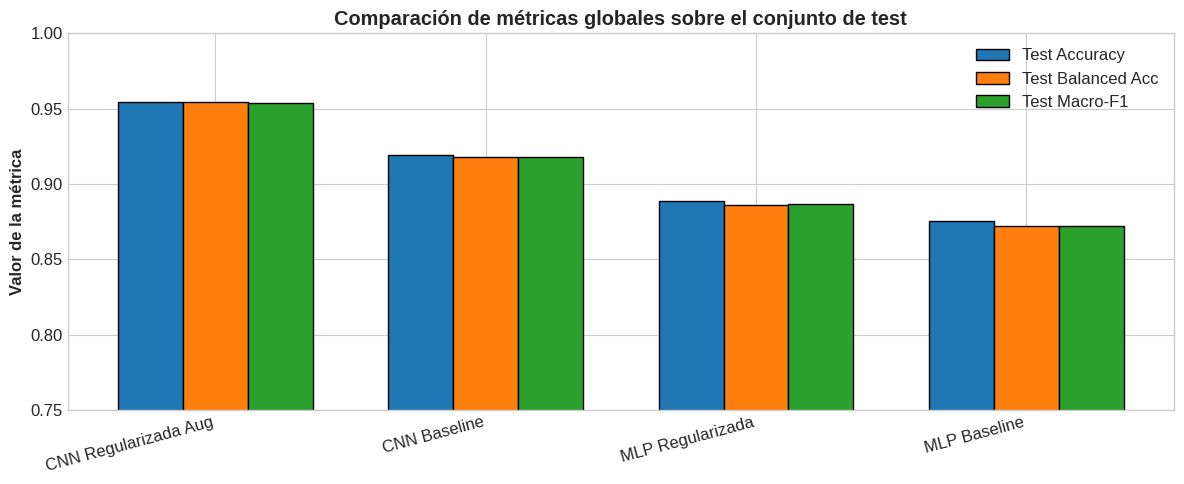

In [26]:
metric_cols = ["Test Accuracy", "Test Balanced Acc", "Test Macro-F1"]
plot_df = results_df.copy()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_df))
width = 0.24

for i, metric in enumerate(metric_cols):
    ax.bar(x + (i - 1) * width, plot_df[metric], width=width, edgecolor="black", label=metric)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Experimento"], rotation=15, ha="right")
ax.set_ylim(0.75, 1.0)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparación de métricas globales sobre el conjunto de test")
ax.legend()
plt.tight_layout()
plt.show()


### Interpretación
- Si la accuracy y la balanced accuracy son parecidas, el modelo está tratando de forma relativamente homogénea a las clases.
- Si la accuracy es bastante mayor que la balanced accuracy, probablemente el modelo está favoreciendo a las clases frecuentes.
- La macro-F1 es especialmente exigente: castiga tanto baja precisión como bajo recall por clase.

### Pregunta de reflexión
¿Qué experimento parece mejorar más las clases minoritarias, y en qué métrica se nota primero?


## 14. Curvas de entrenamiento

Las curvas nos muestran la dinámica del aprendizaje:

- cómo baja la pérdida;
- cuándo aparece sobreajuste;
- cuánto se achica la brecha entre entrenamiento y validación.

### Error conceptual frecuente
Comparar sin pensar la train loss y la val loss cuando hay augmentation y dropout. En esos casos, el conjunto de entrenamiento es efectivamente más difícil que el de validación.


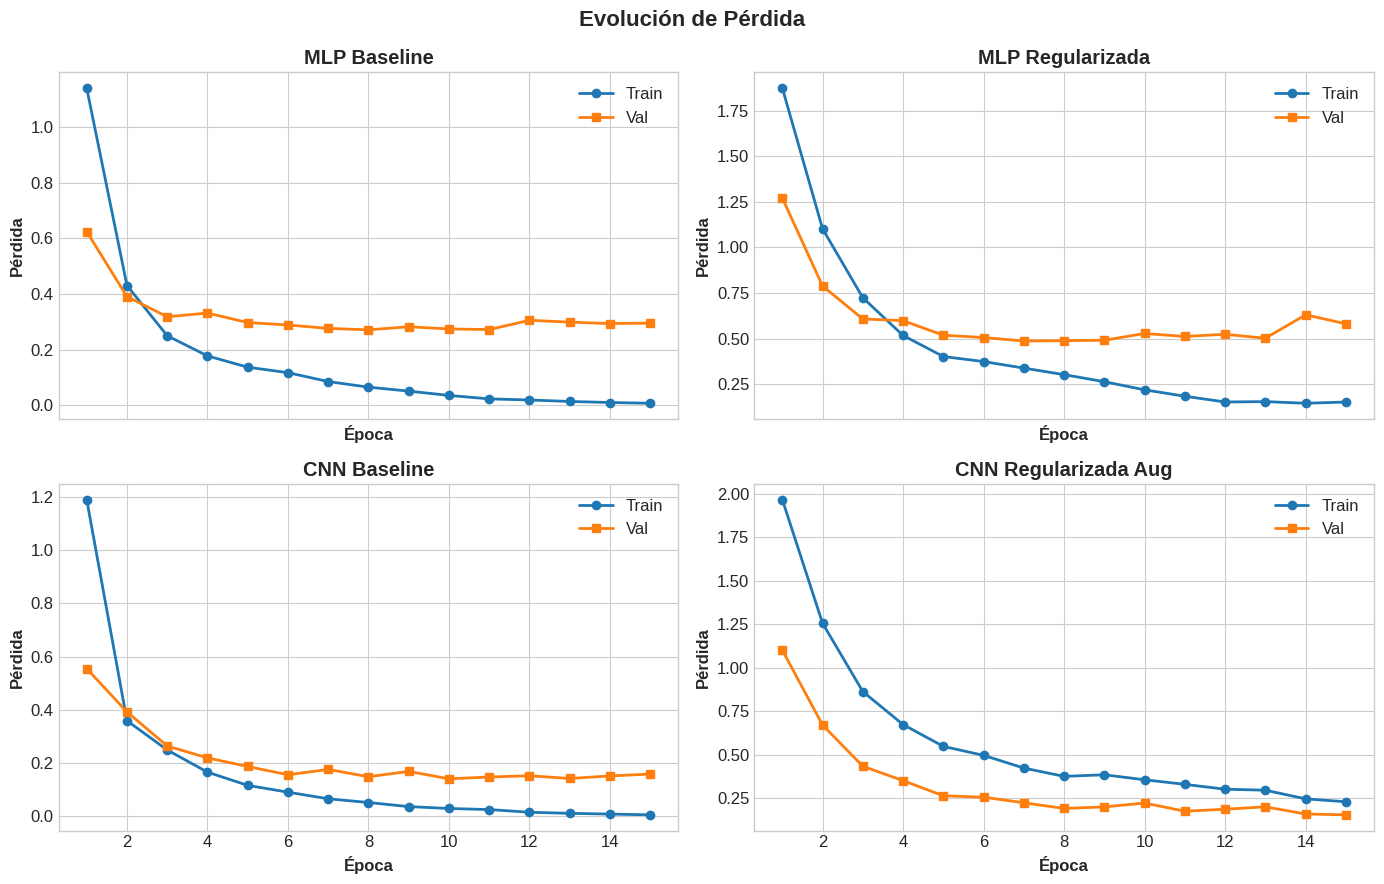

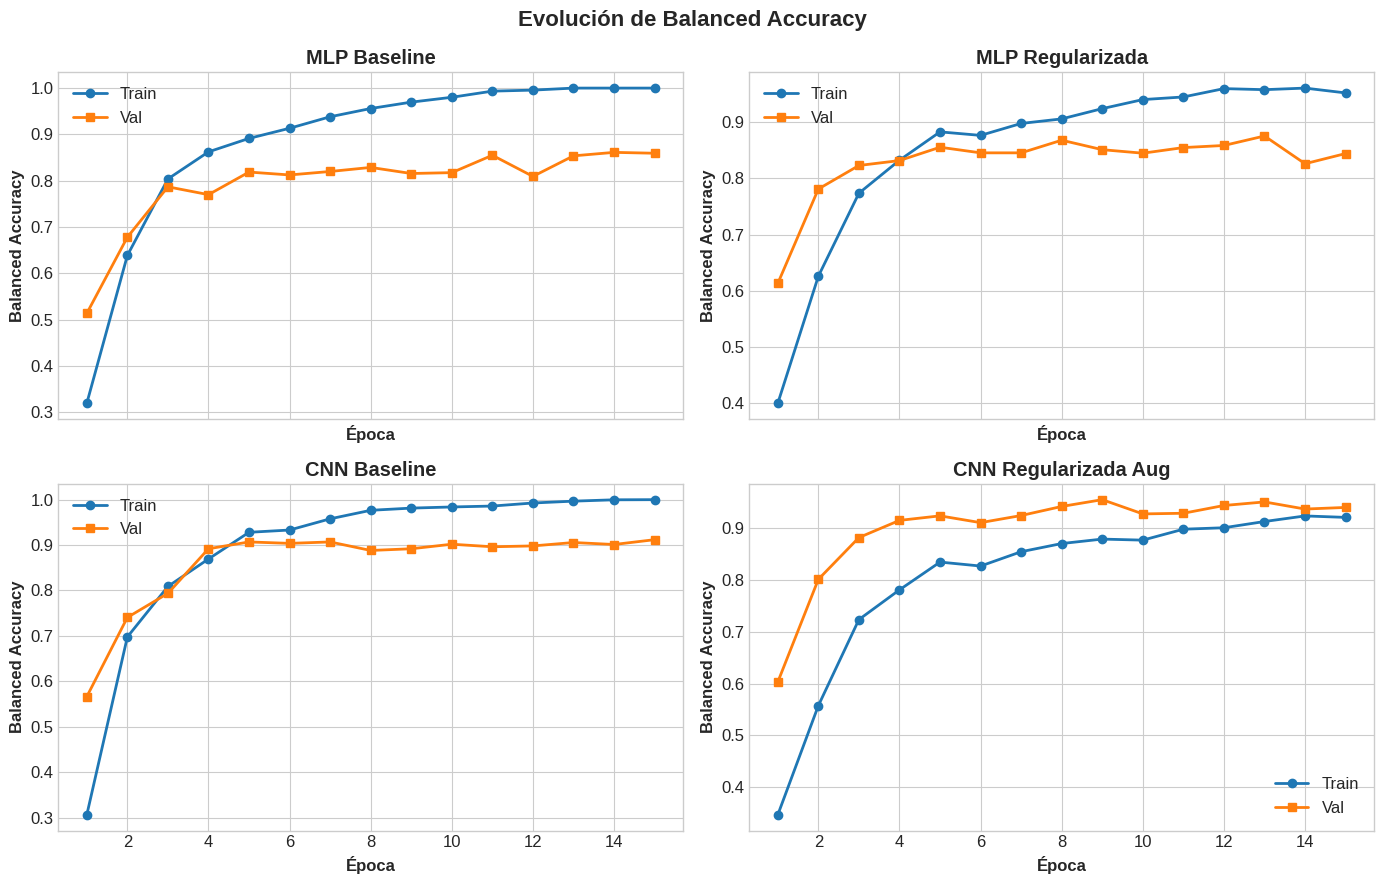

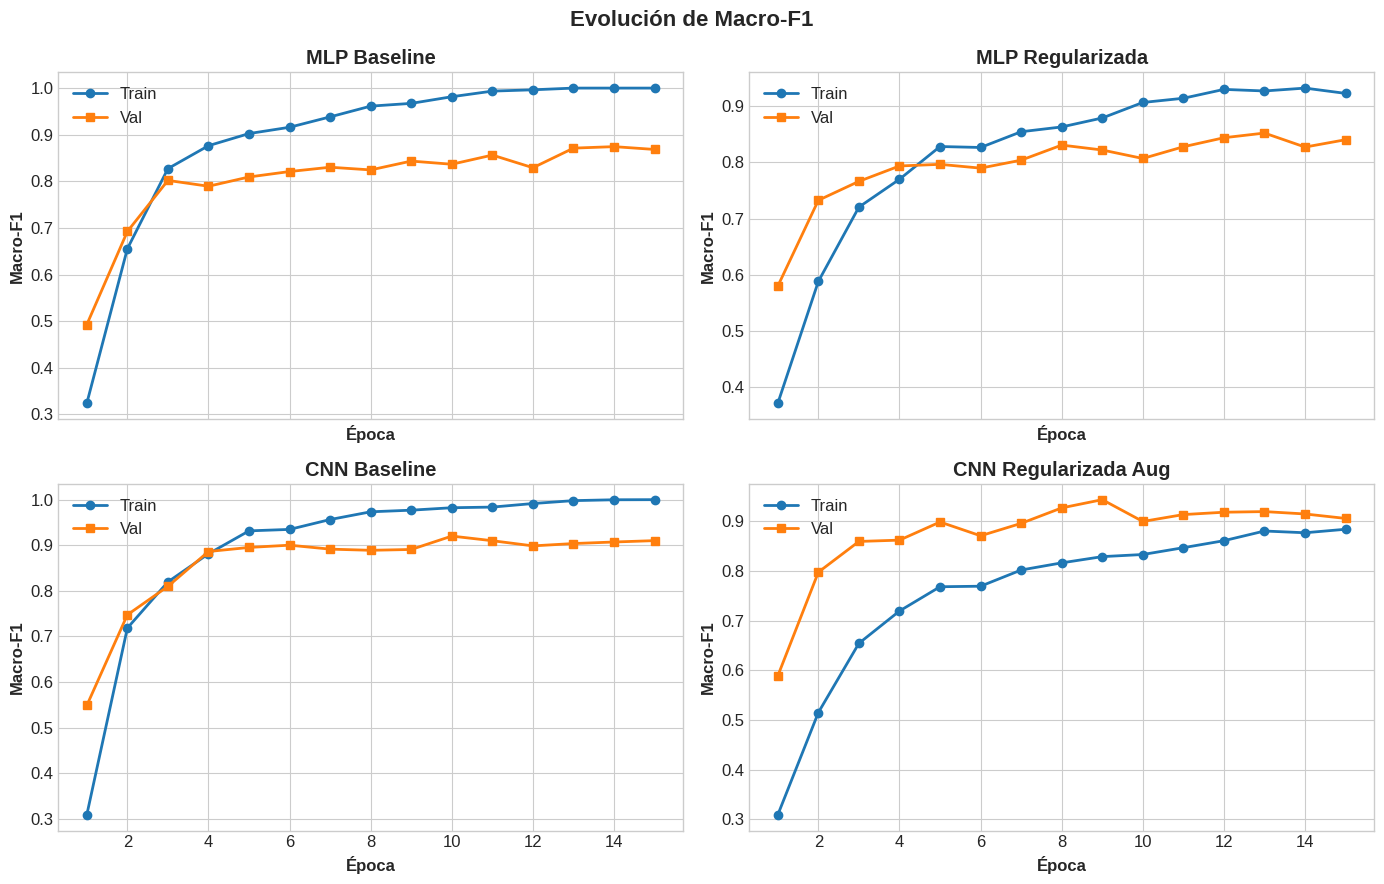

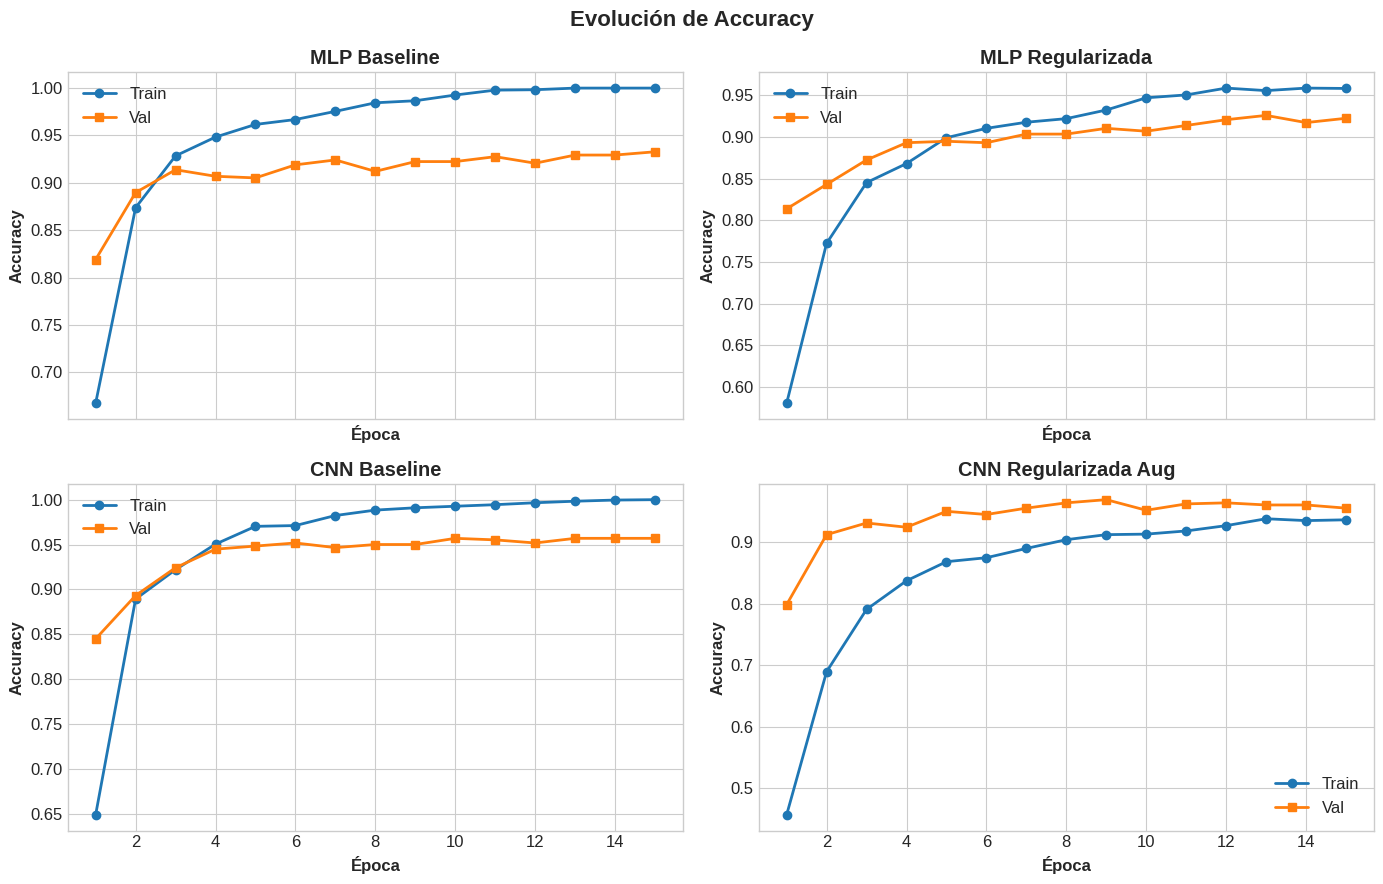

In [27]:
def plot_histories_grid(histories: Dict[str, Dict[str, List[float]]], metric_pairs=None):
    if metric_pairs is None:
        metric_pairs = [
            ("train_loss", "val_loss", "Pérdida"),
            ("train_bal_acc", "val_bal_acc", "Balanced Accuracy"),
            ("train_macro_f1", "val_macro_f1", "Macro-F1"),
            ("train_accuracy", "val_accuracy", "Accuracy"),
        ]

    for train_key, val_key, title in metric_pairs:
        fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
        axes = axes.flatten()

        for ax, (name, hist) in zip(axes, histories.items()):
            epochs_range = range(1, len(hist[train_key]) + 1)
            ax.plot(epochs_range, hist[train_key], marker="o", linewidth=2, label="Train")
            ax.plot(epochs_range, hist[val_key], marker="s", linewidth=2, label="Val")
            ax.set_title(name.replace("_", " "))
            ax.set_xlabel("Época")
            ax.set_ylabel(title)
            ax.legend()

        fig.suptitle(f"Evolución de {title}", fontsize=16, fontweight="bold", y=0.98)
        plt.tight_layout()
        plt.show()

plot_histories_grid(histories)


In [28]:
gap_rows = []
for name, hist in histories.items():
    best_epoch = int(np.argmax(hist["val_macro_f1"]))
    gap_rows.append({
        "Experimento": name.replace("_", " "),
        "best_epoch": best_epoch + 1,
        "gap_bal_acc_best_epoch": hist["train_bal_acc"][best_epoch] - hist["val_bal_acc"][best_epoch],
        "gap_macro_f1_best_epoch": hist["train_macro_f1"][best_epoch] - hist["val_macro_f1"][best_epoch],
    })

gap_df = pd.DataFrame(gap_rows)
display(gap_df)


,Experimento,best_epoch,gap_bal_acc_best_epoch,gap_macro_f1_best_epoch
0,MLP Baseline,14,0.138750,0.125562
1,MLP Regularizada,13,0.082500,0.074809
2,CNN Baseline,10,0.082031,0.062164
3,CNN Regularizada Aug,9,-0.076094,-0.114730


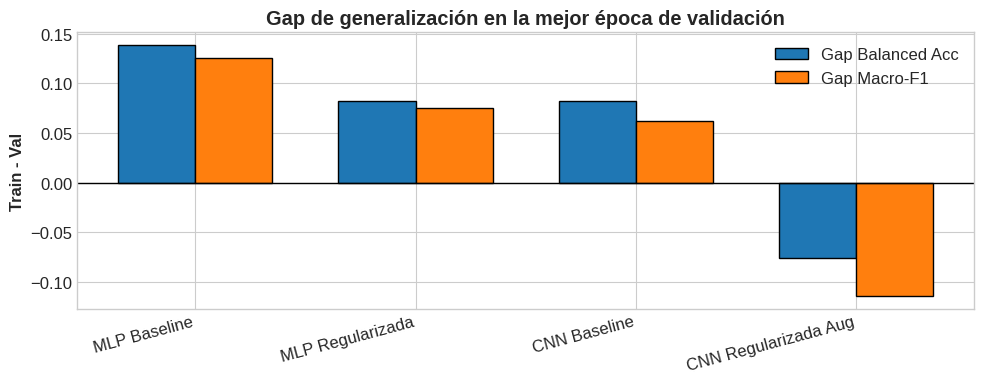

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(gap_df))
width = 0.35

ax.bar(x - width/2, gap_df["gap_bal_acc_best_epoch"], width=width, edgecolor="black", label="Gap Balanced Acc")
ax.bar(x + width/2, gap_df["gap_macro_f1_best_epoch"], width=width, edgecolor="black", label="Gap Macro-F1")

ax.axhline(0.0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(gap_df["Experimento"], rotation=15, ha="right")
ax.set_ylabel("Train - Val")
ax.set_title("Gap de generalización en la mejor época de validación")
ax.legend()
plt.tight_layout()
plt.show()


### Mensaje para llevarse
- Un gap grande `train > val` suele indicar sobreajuste.
- Si el gap es pequeño y la validación es buena, el modelo está generalizando mejor.
- En modelos con augmentation y dropout, no es raro que el entrenamiento resulte más duro que la validación.


## 15. Anatomía del error: matrices de confusión

Las métricas globales resumen, pero no muestran dónde se equivoca el modelo.

La matriz de confusión sí lo hace.

Vamos a usar matrices normalizadas por fila: cada fila representa una clase real y suma aproximadamente 1. Por eso, la diagonal se interpreta como el recall por clase.


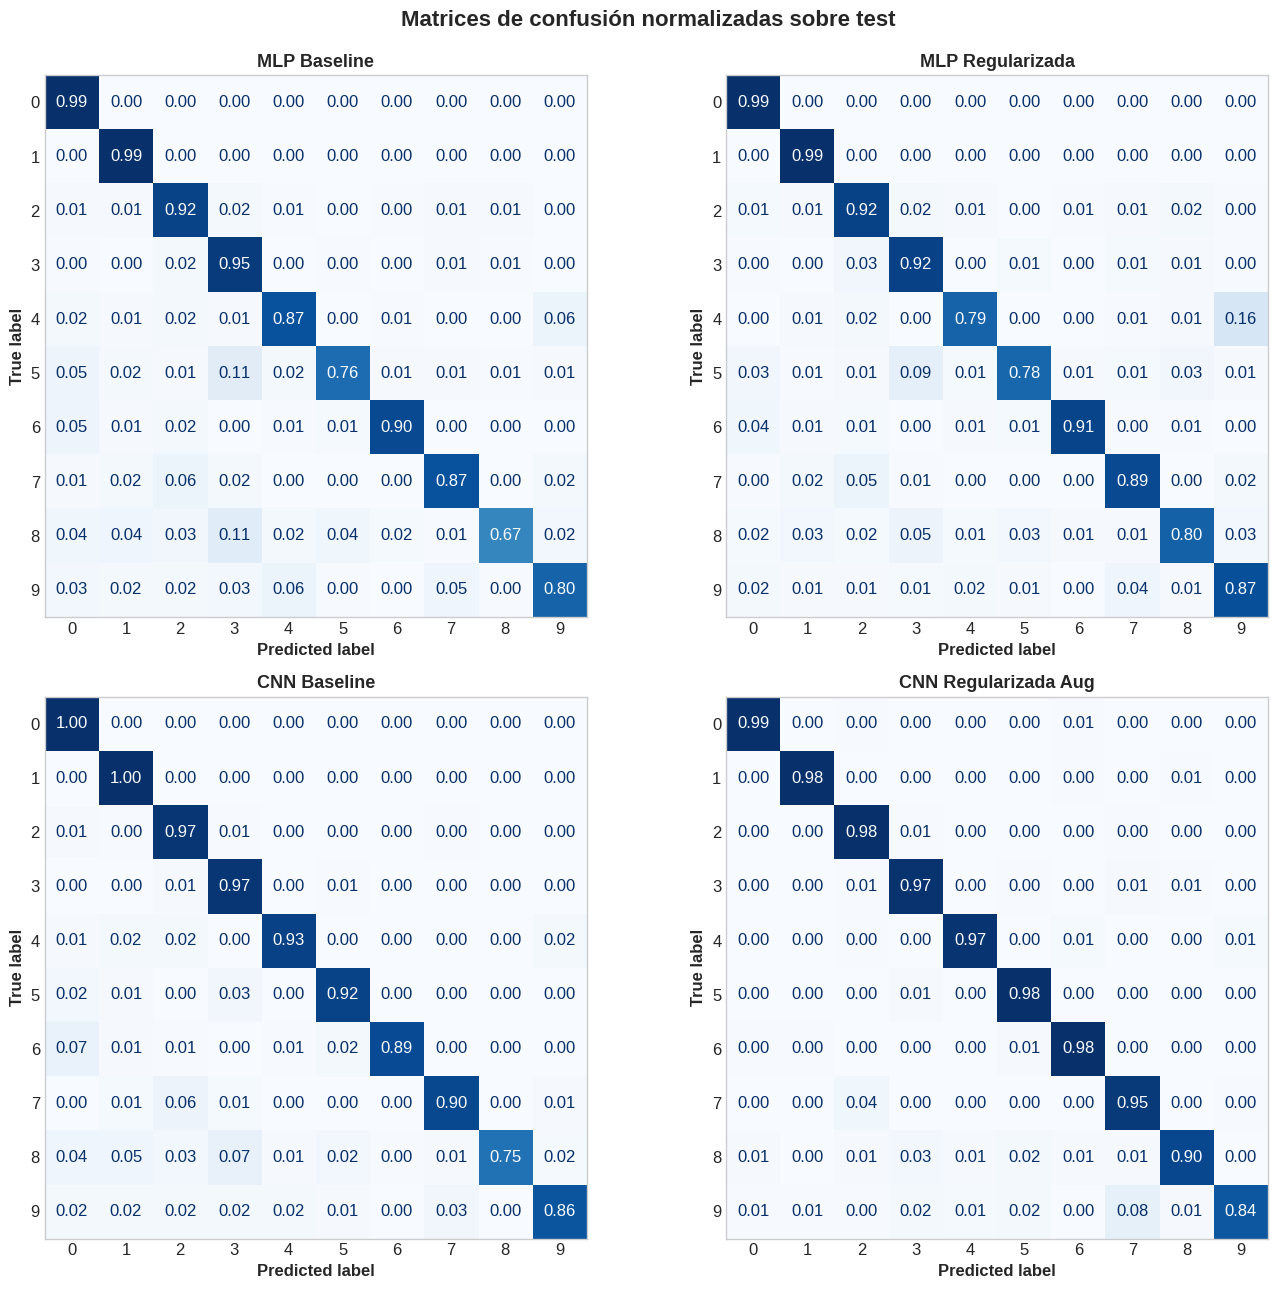

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 13))
axes = axes.flatten()

for ax, exp in zip(axes, EXPERIMENTS):
    name = exp["name"]
    preds = trained_models[name]["test_preds"]
    true = trained_models[name]["test_true"]

    cm = confusion_matrix(true, preds, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(name.replace("_", " "), fontsize=13, fontweight="bold")
    ax.grid(False)

fig.suptitle("Matrices de confusión normalizadas sobre test", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


In [31]:
def per_class_recall_from_confusion(y_true, y_pred, num_classes=10):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    return np.diag(cm)

recall_rows = []
for exp in EXPERIMENTS:
    name = exp["name"]
    recalls = per_class_recall_from_confusion(
        trained_models[name]["test_true"],
        trained_models[name]["test_preds"],
    )
    row = {"Experimento": name.replace("_", " ")}
    for c, value in enumerate(recalls):
        row[f"Clase {c}"] = value
    recall_rows.append(row)

per_class_df = pd.DataFrame(recall_rows).set_index("Experimento")
display(per_class_df)


,Clase 0,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5,Clase 6,Clase 7,Clase 8,Clase 9
Experimento,,,,,,,,,,
MLP Baseline,0.994898,0.993833,0.920543,0.950495,0.869654,0.763453,0.895616,0.867704,0.668378,0.798811
MLP Regularizada,0.988776,0.986784,0.916667,0.919802,0.792261,0.783632,0.909186,0.891051,0.799795,0.871160
CNN Baseline,0.996939,0.995595,0.969961,0.973267,0.929735,0.921525,0.889353,0.899805,0.746407,0.855302
CNN Regularizada Aug,0.987755,0.982379,0.980620,0.973267,0.968432,0.982063,0.982255,0.947471,0.896304,0.840436


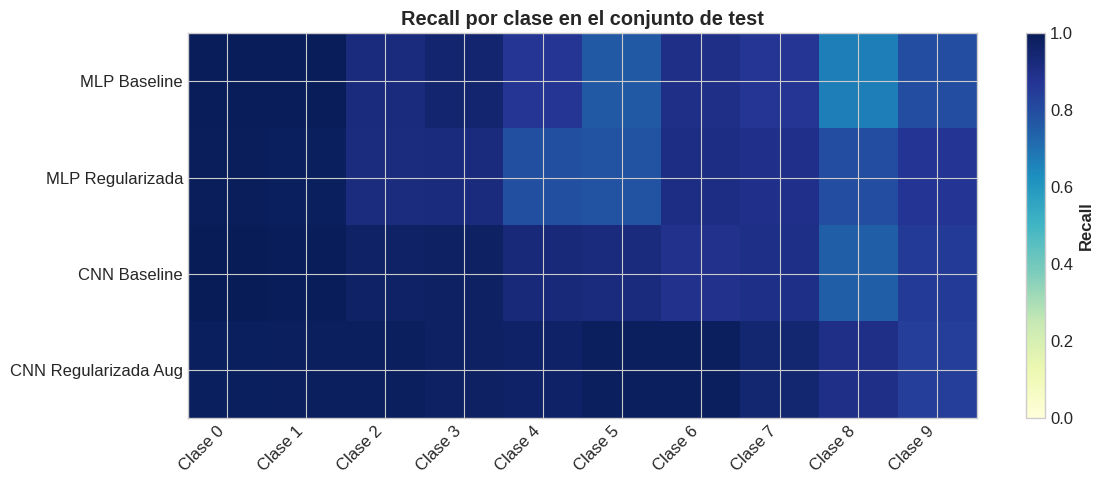

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(per_class_df.values, aspect="auto", cmap="YlGnBu", vmin=0.0, vmax=1.0)

ax.set_xticks(np.arange(per_class_df.shape[1]))
ax.set_xticklabels(per_class_df.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(per_class_df.shape[0]))
ax.set_yticklabels(per_class_df.index)
ax.set_title("Recall por clase en el conjunto de test")
fig.colorbar(im, ax=ax, label="Recall")
plt.tight_layout()
plt.show()


In [33]:
def top_confusions(y_true, y_pred, top_k=10):
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)
    pairs = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                pairs.append((i, j, cm[i, j]))
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    return pairs[:top_k]

for exp in EXPERIMENTS:
    name = exp["name"]
    print(f"\n{name}")
    for i, j, n in top_confusions(trained_models[name]["test_true"], trained_models[name]["test_preds"], top_k=5):
        print(f"  Clase real {i} → predicha como {j}: {n} veces")



MLP_Baseline
  Clase real 8 → predicha como 3: 112 veces
  Clase real 5 → predicha como 3: 100 veces
  Clase real 9 → predicha como 4: 62 veces
  Clase real 4 → predicha como 9: 60 veces
  Clase real 7 → predicha como 2: 60 veces

MLP_Regularizada
  Clase real 4 → predicha como 9: 154 veces
  Clase real 5 → predicha como 3: 76 veces
  Clase real 7 → predicha como 2: 54 veces
  Clase real 8 → predicha como 3: 53 veces
  Clase real 9 → predicha como 7: 42 veces

CNN_Baseline
  Clase real 8 → predicha como 3: 69 veces
  Clase real 6 → predicha como 0: 64 veces
  Clase real 7 → predicha como 2: 60 veces
  Clase real 8 → predicha como 1: 45 veces
  Clase real 8 → predicha como 0: 41 veces

CNN_Regularizada_Aug
  Clase real 9 → predicha como 7: 84 veces
  Clase real 7 → predicha como 2: 37 veces
  Clase real 8 → predicha como 3: 27 veces
  Clase real 9 → predicha como 3: 22 veces
  Clase real 8 → predicha como 5: 21 veces


### Interpretación
- Las clases minoritarias suelen mostrar recalls más bajos en los modelos baseline.
- Cuando aparece `class-weighted loss`, el modelo suele dedicar más capacidad a no abandonar esas clases.
- La CNN, incluso sin regularización, tiende a cometer errores más “estructurados” y menos arbitrarios que la MLP.

### Pregunta para discutir
¿Las mejoras en las clases minoritarias vienen más por la arquitectura, por la regularización, o por la combinación de ambas?


## 16. Discusión conceptual integradora

A esta altura ya deberías poder sostener varias ideas importantes con evidencia empírica.

### 16.1 MLP vs CNN
La MLP recibe una imagen como un vector. Eso le quita estructura espacial al problema. La CNN, en cambio, aprovecha:

- vecindad local,
- compartición de pesos,
- jerarquía de patrones.

Por eso no sorprende que, incluso con más parámetros, la CNN generalice mejor en imágenes.

### 16.2 Overfitting
Cuando la pérdida de entrenamiento cae muy rápido y la de validación deja de acompañar, aparece el sobreajuste. En datasets pequeños esto es esperable, especialmente en modelos densos.

### 16.3 Regularización
- **Dropout** dificulta la co-adaptación de neuronas.
- **Weight decay** desalienta pesos excesivamente grandes.
- **Augmentation** vuelve más difícil el entrenamiento y empuja a aprender invariancias útiles.
- **Class-weighted loss** compensa parcialmente el sesgo estadístico del dataset.

### 16.4 Métricas
- **Accuracy**: útil, pero insuficiente si hay desbalance.
- **Balanced Accuracy**: excelente para ver si el modelo ignora clases.
- **Macro-F1**: particularmente severa y muy informativa.

### Mensaje para llevarse
En Deep Learning no alcanza con mirar un número final. Hay que entender:

- el régimen de datos,
- la arquitectura,
- la regularización,
- las métricas,
- y la estructura de los errores.


## 17. Preguntas para clase

1. ¿Por qué el MNIST original puede ser demasiado fácil para comparar modelos?
2. ¿Qué evidencia concreta de overfitting aparece en la MLP baseline?
3. ¿Por qué una CNN puede generalizar mejor aunque tenga más parámetros?
4. ¿En qué sentido el data augmentation actúa como regularizador?
5. ¿Qué diferencia conceptual hay entre balanced accuracy y macro-F1?
6. ¿Qué te dicen las matrices de confusión que no te dice la accuracy?
7. ¿Qué pasaría si elimináramos por completo las clases 8 y 9 del entrenamiento?
8. ¿Qué esperarías que ocurra si duplicamos el tamaño del subset manteniendo el mismo desbalance?


## 18. Extensiones sugeridas

Estas extensiones son ideales para convertir esta guía en una consigna más abierta:

- agregar `BatchNorm` a la CNN;
- comparar `class-weighted loss` versus `weighted sampling`;
- modificar el perfil de desbalance;
- reducir todavía más el tamaño del dataset;
- repetir el experimento con distintas semillas;
- probar una CNN con una capa adicional;
- analizar ejemplos concretos mal clasificados;
- registrar también precision y recall por clase;
- comparar el mismo experimento sin normalización;
- estudiar cómo cambia el resultado si elegimos el mejor modelo por `val_bal_acc` en lugar de `val_macro_f1`.


## 19. Errores frecuentes de interpretación

- **“La accuracy es alta, entonces el modelo está bien.”**  
  Falso: puede estar ignorando clases minoritarias.

- **“La CNN gana sólo porque tiene más parámetros.”**  
  Incompleto: también gana por su sesgo inductivo.

- **“Si la train loss es mayor que la val loss, hay un bug.”**  
  No necesariamente: con augmentation y dropout el train puede ser más difícil.

- **“Regularización siempre mejora todo al mismo tiempo.”**  
  No: a veces sacrifica algo de accuracy global para mejorar clases difíciles.

- **“Más complejidad siempre da mejor generalización.”**  
  No: depende del tamaño del dataset, del problema y de la arquitectura.


## 20. Conclusión

Este trabajo práctico muestra que un problema aparentemente “simple” como MNIST puede transformarse en una excelente plataforma para estudiar ideas profundas de aprendizaje profundo si cambiamos el régimen de datos.

Al reducir drásticamente el conjunto de entrenamiento y desbalancear las clases, aparecen de manera visible:

- el overfitting;
- la importancia del sesgo inductivo;
- el papel de la regularización;
- la necesidad de usar métricas adecuadas;
- y el valor de analizar cómo se equivoca un modelo, no sólo cuánto acierta.

### Cierre
La lección central no es que “las CNN ganan a las MLP”.

La lección central es que **arquitectura, datos, regularización y métrica forman un sistema**. Entender ese sistema es una parte esencial de aprender Deep Learning.


## 21. Entregables sugeridos

Para la entrega, se espera que cada grupo incluya:

1. las arquitecturas implementadas;
2. el loop de entrenamiento completo;
3. tablas y gráficos finales;
4. una discusión conceptual breve respondiendo:
   - qué modelo generalizó mejor;
   - qué efecto tuvo la regularización;
   - qué métrica resultó más informativa;
   - qué clases fueron más difíciles y por qué.

Podés agregar variantes propias, pero asegurate de conservar la comparación base entre **MLP** y **CNN**.
